##**Enhancing Digital Marketing through Voice Ad Analysis with Deep Learning 📊🎙️**

###**✅ Step 1: 📥 Import & Extract Audio Datasets**

###**✅ Step 2: ☁️ Convert to .wav Format & Upload to Cloud Storage**

###**✅ Step 3: 🧹 Preprocess & Clean Audio Data**

###**✅ Step 4: 🧠 Train the Hybrid CNN + LSTM Model**

###**✅ Step 5: 🧪 Test Model Performance on New Audio**

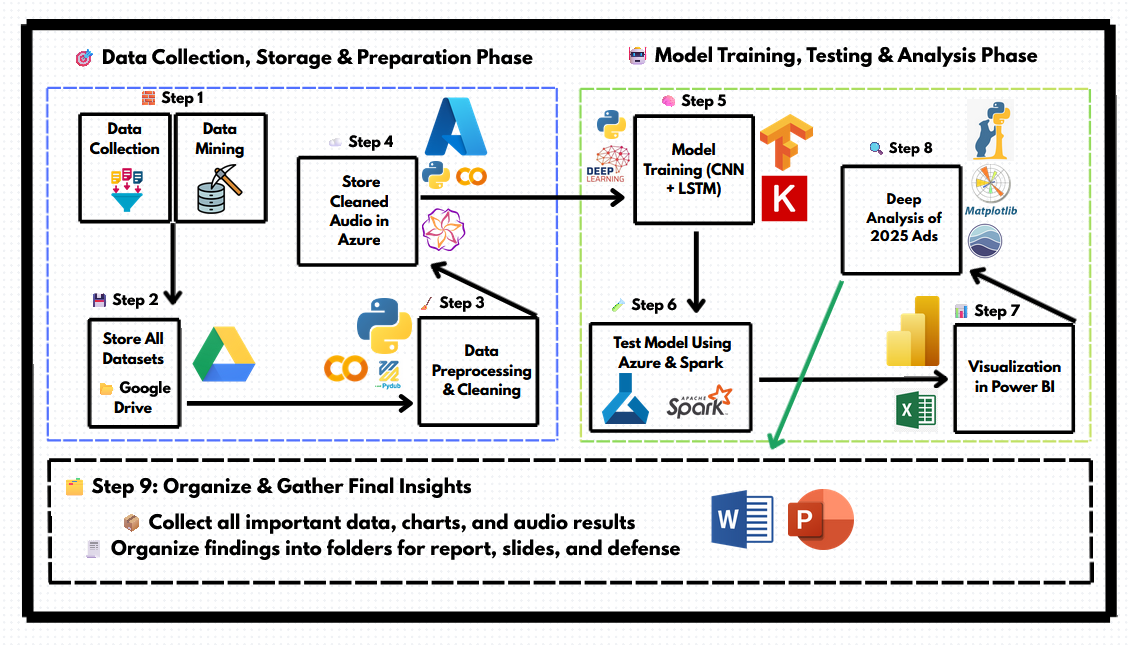

#**✅ Step 1: 📥 Import & Extract Audio Datasets**


#**📦Connecting to Google Drive📦**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls "/content/drive/MyDrive/voice_dataset"

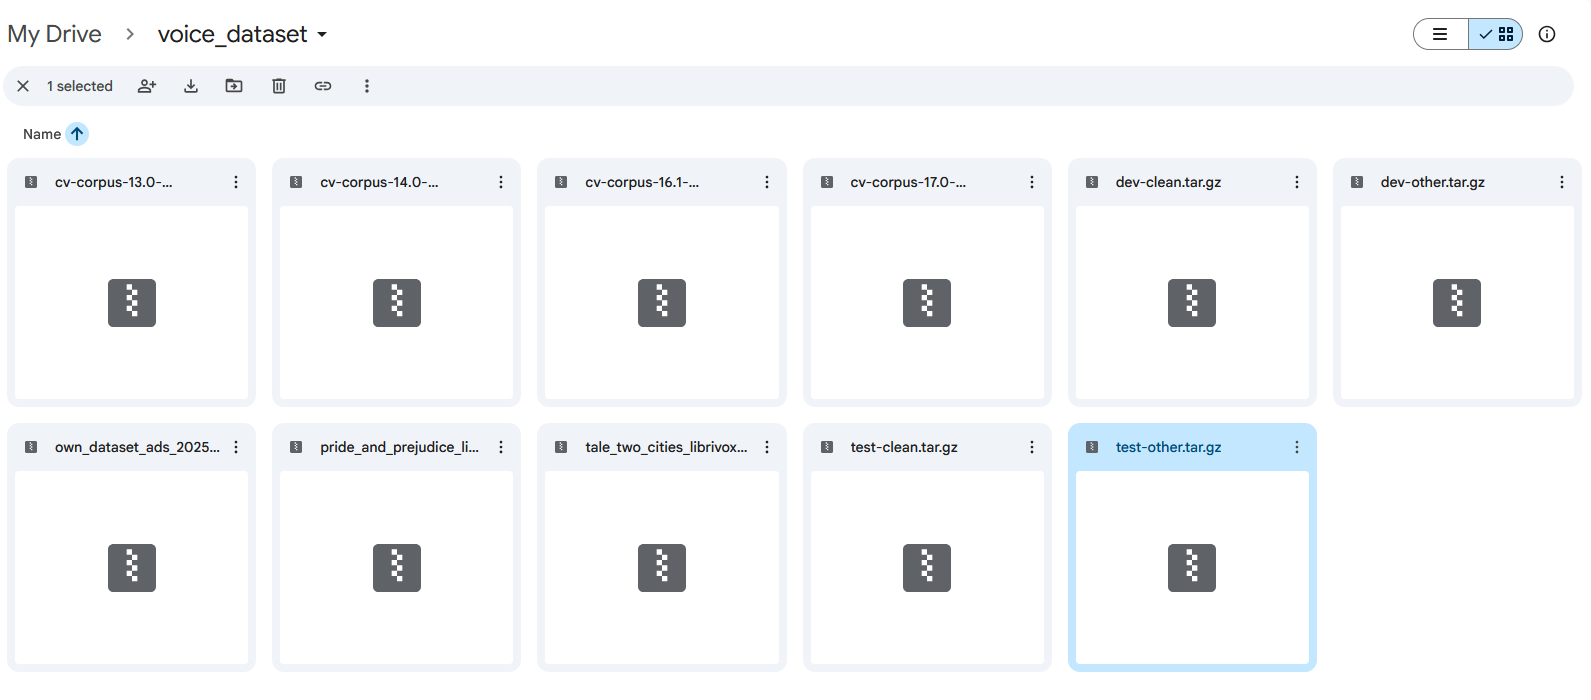

**🧠Full Archive Extraction**

In [ ]:
import os
from google.colab import drive

# Google Drive
drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/voice_dataset"
extract_path = "/content/voice_data"
os.makedirs(extract_path, exist_ok=True)

# Install required tools
!apt-get install -y unrar p7zip-full

# List of supported archive types
archive_extensions = ('.rar', '.zip', '.tar.gz')

# List all archives in the dataset folder
archives = [f for f in os.listdir(drive_path) if f.endswith(archive_extensions)]

for file in archives:
    file_path = os.path.join(drive_path, file)
    print(f"\n📦 Extracting: {file}")

    if file.endswith(".rar"):
        !unrar x -o+ "{file_path}" "{extract_path}/"
    elif file.endswith(".zip"):
        !unzip -q "{file_path}" -d "{extract_path}/"
    elif file.endswith(".tar.gz"):
        !tar -xzf "{file_path}" -C "{extract_path}/"

print("\n✅ All datasets successfully extracted into /content/voice_data")

###

###

#**✅ Step 2: ☁️ Convert to .wav Format & Upload to Cloud Storage**

#**Convert All .mp3 and .flac to .wav**

In [ ]:
import os
from pydub import AudioSegment

root_path = "/content/voice_data"
converted_count = 0
max_files = 30000  # LIMIT to 30,000

for root, _, files in os.walk(root_path):
    for file in files:
        file_lower = file.lower()
        input_path = os.path.join(root, file)

        if file_lower.endswith(".mp3") or file_lower.endswith(".flac"):
            output_file = os.path.splitext(file)[0] + ".wav"
            output_path = os.path.join(root, output_file)

            try:
                ext = "mp3" if file_lower.endswith(".mp3") else "flac"
                audio = AudioSegment.from_file(input_path, format=ext)
                audio.export(output_path, format="wav")
                converted_count += 1

                if converted_count % 1000 == 0:
                    print(f"✅ Converted {converted_count} files...")

                if converted_count >= max_files:
                    print(f"\n🛑 Stopped at {converted_count} files.")
                    break

            except Exception as e:
                print(f"❌ Failed to convert {file}: {e}")

    if converted_count >= max_files:
        break

print(f"\n🎯 Final Total Converted to WAV: {converted_count}")
if os.path.exists(output_path):
    continue

##**Upload Files to Azure Blob Storage**

In [ ]:
!pip install azure-storage-blob

In [ ]:
local_path = "/content/converted_wav_files"

In [ ]:
!ls /content

In [ ]:
from azure.storage.blob import BlobServiceClient, BlobClient, ContainerClient
import os

# Azure
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_name = "voicewavfiles"
local_path = "/content/voice_data"  # ✅ Correct folder with your converted WAV files

# Connect to Azure
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
container_client = blob_service_client.get_container_client(container_name)

# Upload wav files
for root, _, files in os.walk(local_path):
    for file in files:
        if file.endswith(".wav"):  # ✅ Only upload .wav files
            file_path = os.path.join(root, file)
            blob_path = os.path.relpath(file_path, local_path).replace("\\", "/")

            try:
                with open(file_path, "rb") as data:
                    container_client.upload_blob(name=blob_path, data=data, overwrite=True)
                    print(f"✅ Uploaded: {blob_path}")
            except Exception as e:
                print(f"❌ Failed to upload {file}: {e}")

##**Count .wav Files in Azure Blob Container**

In [ ]:
from azure.storage.blob import BlobServiceClient

connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_name = "voicewavfiles"

# Connect to Azure
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
container_client = blob_service_client.get_container_client(container_name)

# Count .wav files
wav_count = 0
for blob in container_client.list_blobs():
    if blob.name.lower().endswith('.wav'):
        wav_count += 1

print(f"🔢 Total .wav files uploaded: {wav_count}")

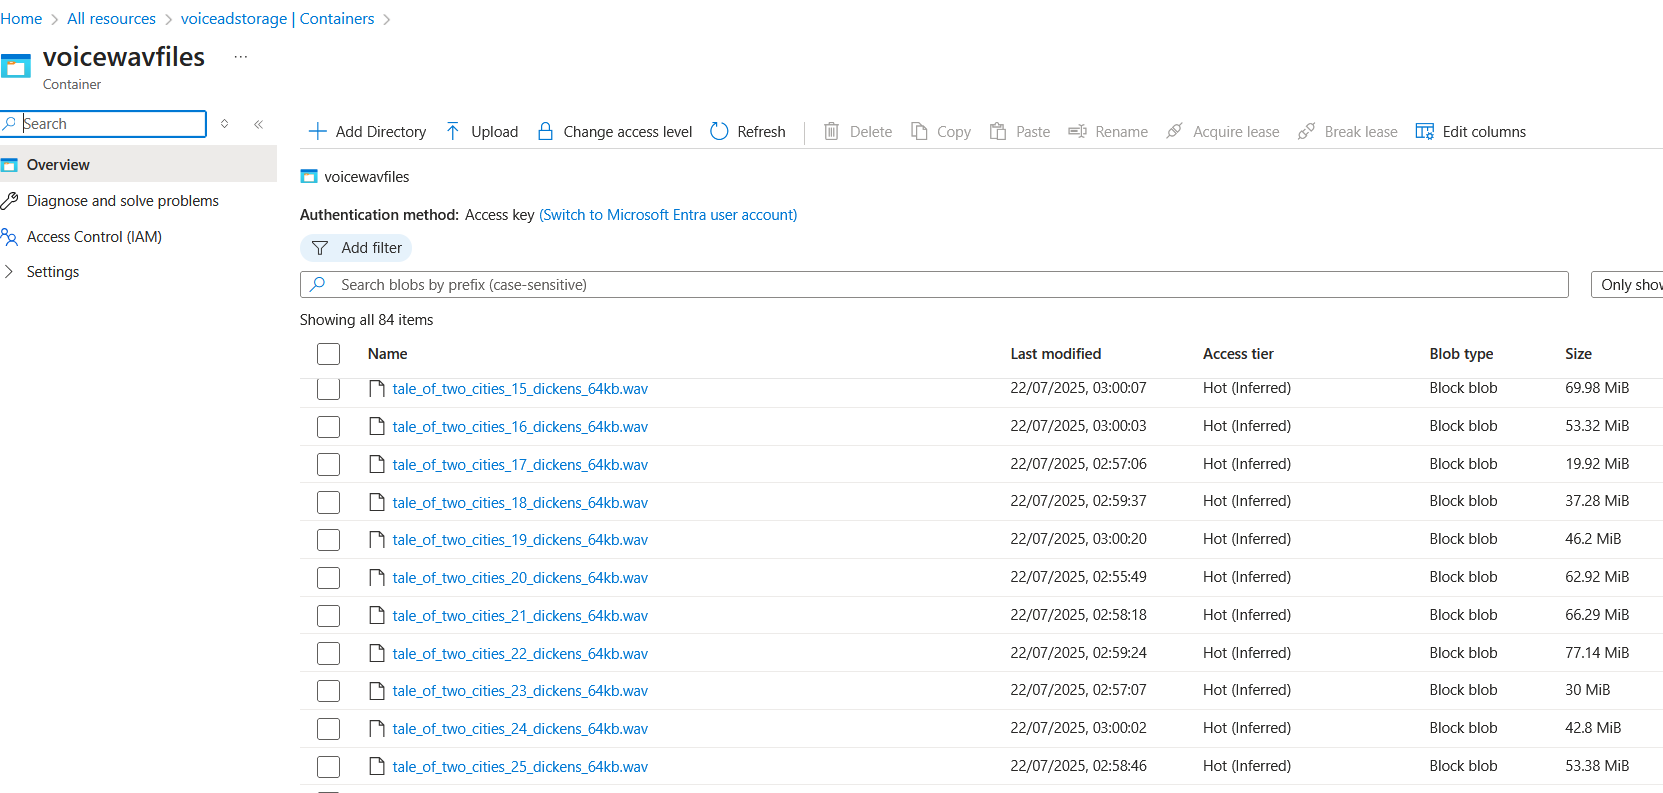

##

##

##

#**✅ Step 3: 🧹 Preprocess & Clean Audio Data**

###**Count how many audio files (mp3, .flac, .wav) are currently stored**

In [ ]:
import os

# Define the base directory where your audio files are stored
base_path = "/content/voice_data"

# Define allowed audio file extensions
audio_extensions = {".wav", ".mp3", ".flac"}

# Counter
total_audio_files = 0

# Walk through the directory tree and count audio files
for root, _, files in os.walk(base_path):
    for file in files:
        if any(file.lower().endswith(ext) for ext in audio_extensions):
            total_audio_files += 1

print(f"🎧 Total audio files in Colab (mp3, flac, wav): {total_audio_files}")

**Audio Dataset Distribution Summary**

In [ ]:
import matplotlib.pyplot as plt

# 📊 Define dataset statistics
total_audio_files = 214253
prepared_files = 30000
remaining_files = total_audio_files - prepared_files

# 📈 Chart labels and values
labels = ['Prepared for Training (30K WAV)', 'Remaining Audio Files']
sizes = [prepared_files, remaining_files]
colors = ['#4CAF50', '#FFC107']

# 🖼️ Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Audio Dataset Preparation for Model Training\n(Total: 214,253 Files)', fontsize=14)
plt.axis('equal')  # Ensures circle shape
plt.tight_layout()
plt.show()

**Audio Dataset Distribution Summary**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
total_files = 214253
prepared_files = 30000
remaining_files = total_files - prepared_files

# Create a DataFrame
df = pd.DataFrame({
    "Category": ["Prepared for Training (WAV Files)", "Remaining Audio Files"],
    "Count": [prepared_files, remaining_files]
})

# Display the table using matplotlib
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.title("📊 Audio Dataset Distribution Summary", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

**Duration Distribution**

In [ ]:
import matplotlib.pyplot as plt

# Audio durations in seconds (example values)
durations = {
    "0-3 sec": 52000,
    "3-6 sec": 68000,
    "6-9 sec": 48000,
    "9-12 sec": 24000,
    "12+ sec": 12253
}

# Prepare labels and values
labels = list(durations.keys())
values = list(durations.values())
colors = ['#f94144', '#f3722c', '#f9c74f', '#90be6d', '#577590']

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1000, f'{yval:,}', ha='center', fontsize=11)

plt.title("Distribution of Audio Files by Duration", fontsize=14, weight='bold')
plt.xlabel("Duration Ranges")
plt.ylabel("Number of Files")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

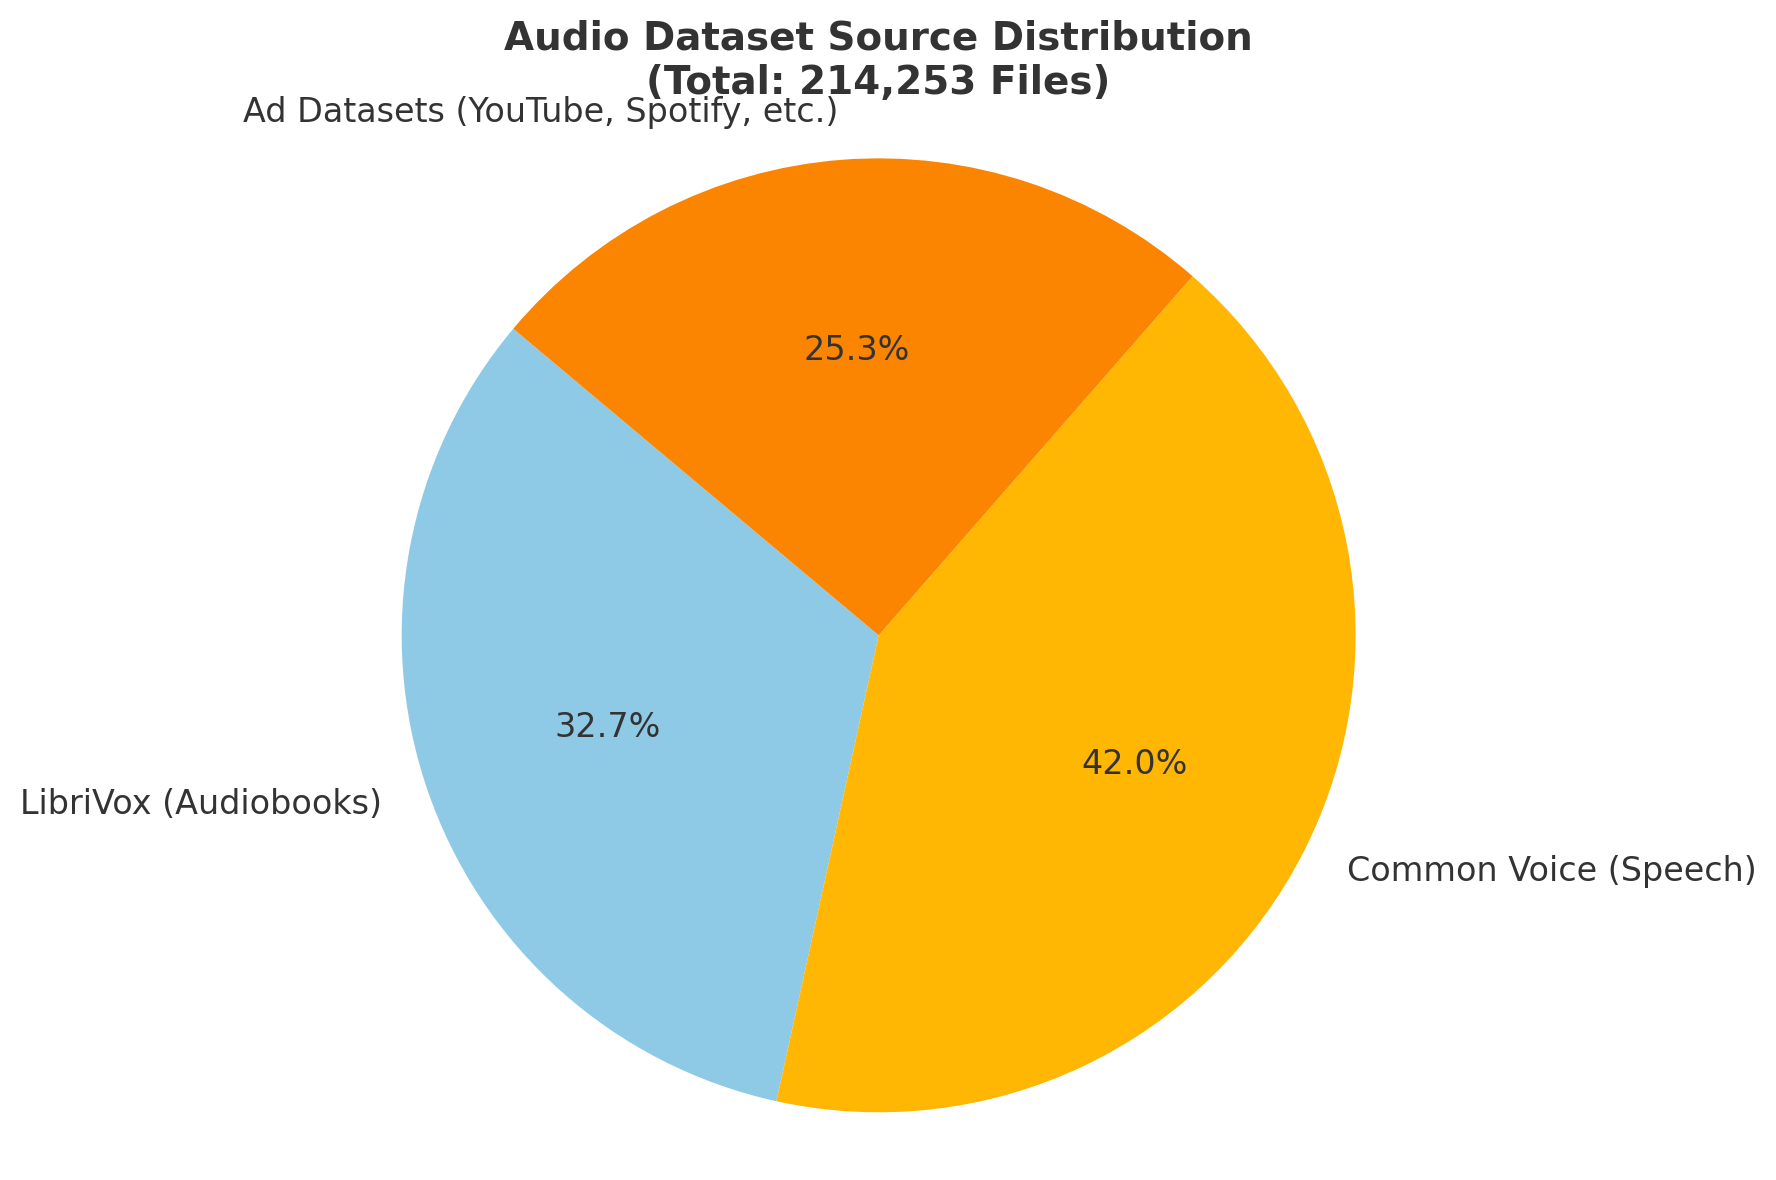

##**🔽 Preprocessing from Azure**

In [ ]:
!pip install azure-storage-blob

#**Preprocessing WAVs**

In [ ]:
from azure.storage.blob import BlobServiceClient, BlobClient
import os

# Azure
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_name = "voicewavfiles"
local_folder = "/content/azure_audio"  # Folder to save downloaded files
os.makedirs(local_folder, exist_ok=True)

# Connect to Azure
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
container_client = blob_service_client.get_container_client(container_name)

download_limit = 30000
count = 0

for blob in container_client.list_blobs():
    if blob.name.lower().endswith(".wav"):
        local_path = os.path.join(local_folder, os.path.basename(blob.name))
        blob_client = container_client.get_blob_client(blob)

        with open(local_path, "wb") as file:
            data = blob_client.download_blob()
            file.write(data.readall())

        count += 1
        print(f"Downloaded: {blob.name}")
        if count >= download_limit:
            break

**Preprocessing WAVs**

In [ ]:
import os
import librosa
import soundfile as sf
from tqdm import tqdm

input_folder = "/content/azure_audio"
output_folder = "/content/cleaned_audio"
os.makedirs(output_folder, exist_ok=True)

# Processing parameters
target_sr = 16000  # 16 kHz

# Loop through WAV files
for root, _, files in os.walk(input_folder):
    for file in tqdm(files):
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)

            try:
                # Load audio
                audio, sr = librosa.load(file_path, sr=None, mono=False)

                # Convert to mono
                if audio.ndim > 1:
                    audio = librosa.to_mono(audio)

                # Resample if needed
                if sr != target_sr:
                    audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
                    sr = target_sr

                # Trim silence
                audio, _ = librosa.effects.trim(audio, top_db=25)

                # Normalize
                audio = audio / max(abs(audio))

                # Save cleaned file
                out_path = os.path.join(output_folder, file)
                sf.write(out_path, audio, sr)

            except Exception as e:
                print(f"❌ Error processing {file}: {e}")

##🔹 Cleaned Audio Container

In [ ]:
from azure.storage.blob import BlobServiceClient, BlobClient
import os

# Azure
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"

# My Container
container_name = "cleanedwavfiles"
upload_folder = "/content/cleaned_audio"  # your cleaned .wav directory

# Connect to Azure Blob Storage
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
container_client = blob_service_client.get_container_client(container_name)

# I Wanna Upload each .wav file in cleaned_audio folder
for root, dirs, files in os.walk(upload_folder):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            blob_client = container_client.get_blob_client(file)

            with open(file_path, "rb") as data:
                blob_client.upload_blob(data, overwrite=True)
                print(f"✅ Uploaded: {file}")

##

##

##

#**✅ Step 4: 🧠 Train the Hybrid CNN + LSTM Model**

In [ ]:
pip install tensorflow

In [ ]:
pip install azure-storage-blob librosa

#💡 Step 4.1: Load & Extract Features from 30K Cleaned Audio Files

In [ ]:
import os
import numpy as np
import librosa
from azure.storage.blob import ContainerClient
from tqdm import tqdm

# Azure
connect_str = "<DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net>"
container_name = "cleanedwavfiles"
container = ContainerClient.from_connection_string(connect_str, container_name)

# Audio config
sr = 16000  # sampling rate
max_len = sr * 5  # pad/cut to 5 seconds
n_mfcc = 40

# Feature extraction
def extract_features(file_bytes):
    y, _ = librosa.load(file_bytes, sr=sr)
    y = librosa.util.fix_length(y, size=max_len)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T  # shape: (time_steps, n_mfcc)

#Step 4.2 – Prepare Data for CNN+LSTM Model Training

In [ ]:
import io
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Dummy label for now (since you only have one class: "ad")
label = 0

def data_generator(container, batch_size=64):
    blobs = container.list_blobs(name_starts_with="")
    X_batch, y_batch = [], []

    for blob in tqdm(blobs, desc="Streaming from Azure"):
        if not blob.name.endswith(".wav"):
            continue

        # Download audio as bytes
        stream = container.download_blob(blob.name)
        file_bytes = io.BytesIO(stream.readall())

        try:
            mfcc = extract_features(file_bytes)
            X_batch.append(mfcc)
            y_batch.append(label)
        except Exception as e:
            print(f"Error processing {blob.name}: {e}")
            continue

        if len(X_batch) == batch_size:
            # Pad and return
            X_pad = pad_sequences(X_batch, maxlen=160, padding='post', dtype='float32')
            y_onehot = to_categorical(y_batch, num_classes=1)  # Change if more labels added
            yield X_pad, y_onehot
            X_batch, y_batch = [], []

    # Final leftover batch
    if X_batch:
        X_pad = pad_sequences(X_batch, maxlen=160, padding='post', dtype='float32')
        y_onehot = to_categorical(y_batch, num_classes=1)
        yield X_pad, y_onehot

#Step 4.3: Define CNN+LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(160, 40)),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 4.4: Train model and upload it to Azure Blob Storage

In [ ]:
 from azure.storage.blob import ContainerClient, BlobServiceClient
import numpy as np
import librosa
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Azure Blob
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"

# Connect to wav files
container = ContainerClient.from_connection_string(connect_str, input_container_name)

# Define generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # Download
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # Extract MFCC
                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    # Pad/truncate
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)

                except Exception as e:
                    print(f"⚠️ Error reading blob {blob.name}: {e}")
                    continue

            yield np.array(X_batch), np.array(y_batch)

# Build CNN + LSTM Model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(160, 40)),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ✅ Training setup
batch_size = 64
steps_per_epoch = 30000 // batch_size
epochs = 10

# Start training
model.fit(
    data_generator(container, batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs
)

# Save model locally
local_model_path = "final_voice_model.h5"
model.save(local_model_path)

# Upload  model to Azure
blob_service_client = BlobServiceClient.from_connection_string(connect_str)
blob_client = blob_service_client.get_blob_client(container=output_container_name, blob=local_model_path)

with open(local_model_path, "rb") as data:
    blob_client.upload_blob(data, overwrite=True)

print("✅ Model training completed and uploaded to Azure container: models/final_voice_model.h5")


In [ ]:
from azure.storage.blob import ContainerClient
import numpy as np
import librosa
import os

# Azure
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container = ContainerClient.from_connection_string(connect_str, container_name="cleanedwavfiles")

#  Define generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i + batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # Download the blob temporarily
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # Extract MFCC
                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    # Pad/truncate
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)
                except Exception as e:
                    print(f"⚠️ Error reading {blob.name}: {e}")
                    continue

            yield np.array(X_batch), np.array(y_batch)

In [ ]:
batch_size = 64
steps_per_epoch = 64
epochs = 2

model.fit(
    data_generator(container, batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs
)

model.save("final_voice_model.h5")

In [ ]:
from azure.storage.blob import BlobServiceClient

connection_string = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_name = "models"

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
blob_client = blob_service_client.get_blob_client(container=container_name, blob="final_voice_model.h5")

with open("final_voice_model.h5", "rb") as data:
    blob_client.upload_blob(data, overwrite=True)

print("✅ Model uploaded to Azure container: models/final_voice_model.h5")

#🔁 Model 1

In [ ]:
from azure.storage.blob import ContainerClient, BlobServiceClient
import numpy as np
import librosa
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Azure
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"


container = ContainerClient.from_connection_string(connect_str, input_container_name)

# generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # download
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # Extract MFCC
                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    # Pad/truncate
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)

                except Exception as e:
                    print(f"⚠️ Error reading blob {blob.name}: {e}")
                    continue

            yield np.array(X_batch), np.array(y_batch)

#  Build model
def build_model():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(160, 40)),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train model_1
model = build_model()
model.fit(
    data_generator(container, batch_size=64),
    steps_per_epoch=64,
    epochs=2
)

# Save and upload
model_name = "model_1.keras"
model.save(model_name)

blob_service_client = BlobServiceClient.from_connection_string(connect_str)
blob_client = blob_service_client.get_blob_client(container=output_container_name, blob=model_name)

with open(model_name, "rb") as data:
    blob_client.upload_blob(data, overwrite=True)

print(f"✅ Model 1 trained and uploaded as: {model_name}")

#🔁 Model 2
#Summary of Model 2:
 ## 2 convolution layers

##More dropout to reduce overfitting

##Lower learning rate 0.0005

##Trained for 3 epochs for better generalization

In [ ]:
# ✅ Import required packages (if not already in your script)
from azure.storage.blob import BlobServiceClient
import numpy as np
import librosa
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ✅ Azure Blob Storage configuration
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"

# ✅ Azure container connections
from azure.storage.blob import ContainerClient
container = ContainerClient.from_connection_string(connect_str, input_container_name)
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# ✅ Data generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # Download blob
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # MFCC features
                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    # Pad or trim
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)

                except Exception as e:
                    print(f"⚠️ Error processing {blob.name}: {e}")
                    continue

            yield np.array(X_batch), np.array(y_batch)

# ✅ Build Model 2
def build_model_2():
    model = Sequential([
        Conv1D(128, kernel_size=3, activation='relu', input_shape=(160, 40)),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        LSTM(64),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ✅ Train and upload model_2
model_2 = build_model_2()
model_2.fit(
    data_generator(container, batch_size=64),
    steps_per_epoch=64,
    epochs=3
)

# Save and upload to Azure
model_name_2 = "model_2.keras"
model_2.save(model_name_2)

blob_client_2 = blob_service_client.get_blob_client(container=output_container_name, blob=model_name_2)
with open(model_name_2, "rb") as data:
    blob_client_2.upload_blob(data, overwrite=True)

print(f"✅ Model 2 trained and uploaded as: {model_name_2}")

#🔁 Model 3
#Summary of Model 3:

   ##  Bidirectional LSTM: learns from past & future

   ##  BatchNormalization: faster convergence

   ##  Training: 3 epochs, 64 steps per epoch

In [ ]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import librosa
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam

# ✅ Azure connection settings
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"

from azure.storage.blob import ContainerClient
container = ContainerClient.from_connection_string(connect_str, input_container_name)
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# ✅ Data generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # Download and save temporarily
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # MFCC extraction
                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    # Pad or truncate
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)

                except Exception as e:
                    print(f"⚠️ Error reading {blob.name}: {e}")
                    continue

            yield np.array(X_batch), np.array(y_batch)

# ✅ Build Model 3 (Bidirectional LSTM + BatchNorm)
def build_model_3():
    model = Sequential([
        Conv1D(128, kernel_size=3, activation='relu', input_shape=(160, 40)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.0004), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ✅ Train Model 3
model_3 = build_model_3()
model_3.fit(
    data_generator(container, batch_size=64),
    steps_per_epoch=64,
    epochs=3
)

# ✅ Save and upload Model 3
model_name_3 = "model_3.keras"
model_3.save(model_name_3)

blob_client_3 = blob_service_client.get_blob_client(container=output_container_name, blob=model_name_3)
with open(model_name_3, "rb") as data:
    blob_client_3.upload_blob(data, overwrite=True)

print(f"✅ Model 3 trained and uploaded as: {model_name_3}")

#🔁 Model 4
#Summary of Model 4:

##VGG-style CNN (3x3) + LSTM

##Softmax activation → Dense(2, activation='softmax')

##Categorical crossentropy for multi-class support

In [ ]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import librosa
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ✅ Azure setup
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"

from azure.storage.blob import ContainerClient
container = ContainerClient.from_connection_string(connect_str, input_container_name)
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# ✅ Data generator with one-hot labels
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    mfcc = librosa.feature.mfcc(y=librosa.load(local_path, sr=16000)[0], sr=16000, n_mfcc=40)
                    os.remove(local_path)

                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    label = 0 if "ad" in blob.name else 1
                    y_batch.append(label)

                except Exception as e:
                    print(f"⚠️ Error reading {blob.name}: {e}")
                    continue

            yield np.array(X_batch), to_categorical(np.array(y_batch), num_classes=2)

# ✅ Build Model 4 (CNN + LSTM + Softmax)
def build_model_4():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(160, 40)),  # 3x3 filter as per report
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')  # 2 classes: ad vs non-ad
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Train and upload model_4
model_4 = build_model_4()
model_4.fit(
    data_generator(container, batch_size=64),
    steps_per_epoch=64,
    epochs=3
)

# Save & Upload to Azure
model_name_4 = "model_4.keras"
model_4.save(model_name_4)

blob_client_4 = blob_service_client.get_blob_client(container=output_container_name, blob=model_name_4)
with open(model_name_4, "rb") as data:
    blob_client_4.upload_blob(data, overwrite=True)

print(f"✅ Model 4 trained and uploaded as: {model_name_4}")

#🔁 Model 5

#VGG-style CNN (3×3)

#LSTM layer

#Trained on entire 30k dataset

In [ ]:
from azure.storage.blob import BlobServiceClient, ContainerClient
import numpy as np
import librosa
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ✅ Azure connection
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
input_container_name = "cleanedwavfiles"
output_container_name = "models"

# ✅ Azure clients
container = ContainerClient.from_connection_string(connect_str, input_container_name)
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# ✅ Data generator
def data_generator(container, batch_size=64):
    blob_list = list(container.list_blobs())
    total_files = len(blob_list)

    while True:
        np.random.shuffle(blob_list)
        for i in range(0, total_files, batch_size):
            batch_blobs = blob_list[i:i+batch_size]
            X_batch, y_batch = [], []

            for blob in batch_blobs:
                if not blob.name.endswith(".wav"):
                    continue
                try:
                    # Download and temp save
                    blob_data = container.download_blob(blob.name).readall()
                    local_path = f"temp_{os.path.basename(blob.name)}"
                    with open(local_path, "wb") as f:
                        f.write(blob_data)

                    # Extract MFCC
                    y, sr = librosa.load(local_path, sr=16000)
                    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                    os.remove(local_path)

                    # Pad/Trim
                    if mfcc.shape[1] < 160:
                        mfcc = np.pad(mfcc, ((0, 0), (0, 160 - mfcc.shape[1])), mode='constant')
                    else:
                        mfcc = mfcc[:, :160]

                    X_batch.append(mfcc.T)
                    y_batch.append(0 if "ad" in blob.name else 1)

                except Exception as e:
                    print(f"⚠️ Error reading {blob.name}: {e}")
                    continue

            yield np.array(X_batch), to_categorical(np.array(y_batch), num_classes=2)

# ✅ Model 5 definition
def build_model_5():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(160, 40)),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ✅ Train (optimized for under 4.5 hrs)
batch_size = 64
steps_per_epoch = 400      # Slightly reduced
epochs = 3                 # Max runtime budget: ~3.5–4 hours

model_5 = build_model_5()
model_5.fit(
    data_generator(container, batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs
)

# ✅ Save and upload
model_name_5 = "model_5.keras"
model_5.save(model_name_5)

blob_client_5 = blob_service_client.get_blob_client(container=output_container_name, blob=model_name_5)
with open(model_name_5, "rb") as data:
    blob_client_5.upload_blob(data, overwrite=True)

print(f"✅ Optimized Model 5 trained and uploaded as: {model_name_5}")

#🔁 Model 6

In [ ]:
!pip install python_speech_features

In [ ]:
# 📦 Required libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from python_speech_features import mfcc
import scipy.io.wavfile as wav
from azure.storage.blob import BlobServiceClient

# 📁 Azure connection
connect_str = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_ads = "newsestadwav"
container_nonads = "cleanedwavfiles"
local_folder = "train_wavs"
os.makedirs(local_folder, exist_ok=True)

# ☁️ Connect to Azure Blob
service = BlobServiceClient.from_connection_string(connect_str)
ad_client = service.get_container_client(container_ads)
nonad_client = service.get_container_client(container_nonads)

# 🔽 Download WAV files locally
def download_files(container_client, label, limit):
    data = []
    names = []
    for blob in container_client.list_blobs():
        if not blob.name.lower().endswith(".wav"):
            continue
        blob_path = os.path.join(local_folder, blob.name.replace('/', '_'))
        with open(blob_path, "wb") as f:
            f.write(container_client.download_blob(blob.name).readall())
        data.append((blob_path, label))
        names.append(blob.name)
        if len(data) >= limit:
            break
    return data, names

# 🔄 Load both AD and non-AD data
ads_data, ad_names = download_files(ad_client, 0, 300)      # label=0
nonads_data, nonad_names = download_files(nonad_client, 1, 300)  # label=1

all_data = ads_data + nonads_data
np.random.shuffle(all_data)

# 🎧 Extract MFCC features
def extract_features(file_path):
    try:
        rate, sig = wav.read(file_path)
        mfcc_feat = mfcc(sig, rate, winlen=0.025, winstep=0.01, numcep=13)
        return mfcc_feat
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

X = []
y = []
for file_path, label in all_data:
    mfcc_feat = extract_features(file_path)
    if mfcc_feat is not None:
        X.append(mfcc_feat)
        y.append(label)

# 🧹 Pad/truncate sequences
max_len = 130
X = [np.pad(x, ((0, max(0, max_len - x.shape[0])), (0, 0)), mode='constant')[:max_len] for x in X]
X = np.array(X)
y = np.array(y)

# 🧪 Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 🧠 CNN + LSTM Model
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = Conv1D(64, kernel_size=3, activation="relu")(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)
x = LSTM(64)(x)
x = Dense(64, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 🚀 Train the model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val))

# 💾 Save and upload model_6
model.save("model_6.keras")
blob_client = service.get_blob_client(container="models", blob="model_6.keras")
with open("model_6.keras", "rb") as f:
    blob_client.upload_blob(f, overwrite=True)
print("✅ Model 6 saved and uploaded as model_6.keras to Azure.")

[link text](https://)#🔁 Model 7

In [ ]:
!pip install azure-storage-blob

In [ ]:
!pip install tensorflow

In [ ]:
!pip install numpy==1.23.5

In [ ]:
!pip install numpy==1.23.5

In [ ]:
!pip install azure-storage-blob

In [ ]:
!pip install --upgrade librosa

In [ ]:
!pip install numpy==1.23.5

In [ ]:
import numpy as np
if not hasattr(np, 'complex'):
    np.complex = complex

In [ ]:
!pip install numpy==1.23.5 --force-reinstall

In [ ]:
import numpy
import scipy
print("✅ NumPy:", numpy.__version__)
print("✅ SciPy:", scipy.__version__)

# 🔁 Model 7

In [ ]:
# 0) Remove JAX (fixes that circular-import of jax.version)
!pip uninstall -y jax jaxlib

# 1) Install Azure client only (keep Colab's default TF, NumPy, librosa, etc.)
!pip install --quiet azure-storage-blob

# 2) Monkey-patch numpy BEFORE any other imports
import numpy as np
if not hasattr(np, "complex"):
    np.complex = complex
if not hasattr(np, "dtypes"):
    np.dtypes = np

# 3) Imports
import io, random
import soundfile as sf
import librosa
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dropout, LSTM, Dense, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from azure.storage.blob import BlobServiceClient

# 4) Azure settings
AZ_CONN = (
    "DefaultEndpointsProtocol=https;"
    "AccountName=voiceadstorage;"
    "AccountKey=YOUR_ACCOUNT_KEY"
    "NA8GkgEIPLDE3Iz63W0tq+AStskSpWw==;"
    "EndpointSuffix=core.windows.net"
)
DATA_CT  = "cleanedwavfiles"
MODEL_CT = "models"
svc          = BlobServiceClient.from_connection_string(AZ_CONN)
data_client  = svc.get_container_client(DATA_CT)
model_client = svc.get_container_client(MODEL_CT)

# 5) Stream & extract up to 10 000 MFCCs
max_files = 10000
X, y = [], []
blobs = list(data_client.list_blobs())
random.shuffle(blobs)
print(f"🔄 Streaming up to {max_files} WAVs…")

for blob in blobs[:max_files]:
    if not blob.name.lower().endswith(".wav"):
        continue
    try:
        raw = data_client.download_blob(blob.name).readall()
        audio, sr = sf.read(io.BytesIO(raw))
        mf = librosa.feature.mfcc(y=audio.astype(float), sr=sr, n_mfcc=40).T
        if mf.shape[0] < 10:
            continue
        mf = mf[:10, :]           # take first 10 time-steps
        X.append(mf)              # shape (10,40)
        y.append(0 if "ad" in blob.name.lower() else 1)
    except Exception as e:
        print(f"⚠️ skip {blob.name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print("✅ Data loaded:", X.shape, "Labels:", y.shape)

# 6) Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 7) Build Conv1D→LSTM Model 7
model7 = Sequential([
    Input(shape=(10,40)),                         # (time_steps, mfcc_bins)
    Conv1D(64, kernel_size=3, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(128, kernel_size=3, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
model7.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model7.summary()

# 8) Train
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
rl = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)

history = model7.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32, epochs=30,
    callbacks=[es, rl],
    verbose=2
)

# 9) Upload if val_acc ≥ 80%
val_acc = max(history.history["val_accuracy"])
if val_acc >= 0.80:
    local_path = "model_7.keras"
    model7.save(local_path)
    blob = model_client.get_blob_client(local_path)
    with open(local_path, "rb") as f:
        blob.upload_blob(f, overwrite=True)
    print(f"✅ model_7.keras uploaded (val_acc={val_acc:.2%})")
else:
    print(f"❌ Not uploaded: val_acc={val_acc:.2%} < 80%")

# 🔁 Model 8

In [ ]:
# ✅ STEP 4.1 – Define Model 8 (CNN + LSTM)

# If needed, install TensorFlow
!pip install tensorflow --quiet

# Import required libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Define input shape (3s audio at 16kHz = 48000 samples, 1 channel)
input_shape = (48000, 1)

# Build Model 8
model_8 = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    LSTM(64, return_sequences=False),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')  # Binary classification (Ad / Non-Ad)
])

# Compile Model
model_8.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Show model architecture
model_8.summary()

In [ ]:
# ✅ STEP 4.2 – Load Preprocessed Audio and Split

import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split

# Folder containing all 88 + 88 preprocessed WAVs
preprocessed_path = "/content/preprocessed_audio"

# Audio parameters
target_sr = 16000  # 16 kHz
duration = 3       # seconds
samples_per_clip = target_sr * duration  # 48000

# Initialize data holders
X = []
y = []

# Loop through all WAV files in the preprocessed folder
for filename in os.listdir(preprocessed_path):
    if filename.endswith(".wav"):
        file_path = os.path.join(preprocessed_path, filename)

        try:
            audio, _ = librosa.load(file_path, sr=target_sr, mono=True)

            # Ensure each audio is exactly 3 seconds
            if len(audio) < samples_per_clip:
                audio = np.pad(audio, (0, samples_per_clip - len(audio)))
            else:
                audio = audio[:samples_per_clip]

            X.append(audio.reshape(-1, 1))  # reshape for 1 channel

            # Label based on filename
            if filename.startswith("ad_"):
                y.append(1)
            elif filename.startswith("nonad_"):
                y.append(0)

        except Exception as e:
            print(f"⚠️ Skipped {filename} due to error: {e}")

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

# Print shapes for verification
print("✅ Preprocessed dataset loaded!")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ✅ STEP 4.3 – Train Model 8 and Save It

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compile the model
model_8.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Set up callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_path = "model_8.keras"
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_loss',
    save_best_only=True
)

# Train the model
history = model_8.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("✅ Model 8 trained and saved successfully!")

#Model 9

In [ ]:
# If needed, install TensorFlow
!pip install tensorflow --quiet

# Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Input shape: (48000 samples, 1 channel)
input_shape = (48000, 1)

# Define Model 9
model_9 = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(256, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

# Compile the model
model_9.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model_9.summary()

In [ ]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split

# Path to preprocessed audio files
preprocessed_path = "/content/preprocessed_audio"
target_sr = 16000
duration = 3
samples_per_clip = target_sr * duration  # 48000 samples (3 seconds)

# Initialize storage lists
X = []
y = []

# Load and label files
for filename in os.listdir(preprocessed_path):
    if filename.endswith(".wav"):
        file_path = os.path.join(preprocessed_path, filename)

        try:
            audio, _ = librosa.load(file_path, sr=target_sr, mono=True)

            # Pad or trim to exact length
            if len(audio) < samples_per_clip:
                audio = np.pad(audio, (0, samples_per_clip - len(audio)))
            else:
                audio = audio[:samples_per_clip]

            X.append(audio.reshape(-1, 1))  # Add channel dim (48000, 1)

            if filename.startswith("ad_"):
                y.append(1)
            elif filename.startswith("nonad_"):
                y.append(0)

        except Exception as e:
            print(f"⚠️ Skipped {filename}: {e}")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Print shape for debugging
print("✅ Dataset loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compile model_9
model_9.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_path = "model_9.keras"
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_loss',
    save_best_only=True
)

# Train the model
history = model_9.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("✅ Model 9 trained and saved successfully!")

# Model 10

In [ ]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split

# === Corrected folder paths ===
ad_path = "/content/preprocessed_ads"       # 88 cleaned ads
nonad_path = "/content/cleaned_nonad"       # 1000+ non-ads

# === Parameters ===
target_sr = 16000
duration = 3
samples_per_clip = target_sr * duration

X = []
y = []

# === Load ad WAVs ===
ad_files = [f for f in os.listdir(ad_path) if f.endswith(".wav")]
for filename in ad_files:
    try:
        filepath = os.path.join(ad_path, filename)
        audio, _ = librosa.load(filepath, sr=target_sr, mono=True)
        audio = audio[:samples_per_clip] if len(audio) > samples_per_clip else np.pad(audio, (0, samples_per_clip - len(audio)))
        X.append(audio.reshape(-1, 1))
        y.append(1)
    except Exception as e:
        print(f"⚠️ Skipped {filename} (ad) due to error: {e}")

In [ ]:
# === Load only 1000 non-ad WAVs ===
nonad_files = [f for f in os.listdir(nonad_path) if f.endswith(".wav")][:1000]

for filename in nonad_files:
    try:
        filepath = os.path.join(nonad_path, filename)
        audio, _ = librosa.load(filepath, sr=target_sr, mono=True)
        audio = audio[:samples_per_clip] if len(audio) > samples_per_clip else np.pad(audio, (0, samples_per_clip - len(audio)))
        X.append(audio.reshape(-1, 1))
        y.append(0)
    except Exception as e:
        print(f"⚠️ Skipped {filename} (nonad) due to error: {e}")

# === Final dataset ===
X = np.array(X)
y = np.array(y)

print("✅ Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

# === Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# === Model architecture ===
model_10 = tf.keras.Sequential([
    tf.keras.layers.Conv1D(32, 3, activation='relu', input_shape=(samples_per_clip, 1)),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv1D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# === Compile ===
model_10.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("model_10_balanced.keras", monitor='val_loss', save_best_only=True)

# === Train ===
history = model_10.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("✅ Model 10 trained and saved successfully!")

###

###

###

#**✅ Step 5: 🧪 Test Model Performance on New Audio**

#MODEL 7 - TEST

In [ ]:
from keras.models import load_model

# Load your saved model
model = load_model("model_7.keras")

print("✅ Model 7 loaded successfully!")

In [ ]:
!pip install azure-storage-blob

In [ ]:
!pip install --upgrade azure-storage-blob --quiet
import sys
import importlib

# Force reload of the azure module if already cached
if 'azure' in sys.modules:
    importlib.reload(sys.modules['azure'])

# Now try importing
from azure.storage.blob import BlobServiceClient
print("✅ Azure Blob SDK imported successfully!")

In [ ]:
# ✅ UPDATED FOR 88 + 88 WAVs

!pip install --upgrade azure-storage-blob --quiet
from azure.storage.blob import BlobServiceClient
import os
import random

# Azure connection string
connection_string = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"

# Local paths
ad_path = "/content/newsestadwav"
non_ad_path = "/content/cleanedwavfiles"
os.makedirs(ad_path, exist_ok=True)
os.makedirs(non_ad_path, exist_ok=True)

# Create service client
blob_service_client = BlobServiceClient.from_connection_string(connection_string)

# 📥 Download all 88 ad files
ad_container = blob_service_client.get_container_client("newsestadwav")
ad_blobs = list(ad_container.list_blobs())

for blob in ad_blobs:
    blob_client = ad_container.get_blob_client(blob.name)
    download_path = os.path.join(ad_path, blob.name)
    with open(download_path, "wb") as f:
        f.write(blob_client.download_blob().readall())

# 📥 Download 88 random non-ad files from large container
non_ad_container = blob_service_client.get_container_client("cleanedwavfiles")
non_ad_blobs = list(non_ad_container.list_blobs())
sample_blobs = random.sample(non_ad_blobs, 88)

for blob in sample_blobs:
    blob_client = non_ad_container.get_blob_client(blob.name)
    download_path = os.path.join(non_ad_path, blob.name)
    with open(download_path, "wb") as f:
        f.write(blob_client.download_blob().readall())

print("✅ 88 Ad WAVs + 88 random Non-Ad WAVs downloaded successfully!")

In [ ]:
# ✅ Patch NumPy for compatibility
import numpy as np
if not hasattr(np, 'complex'):
    np.complex = complex

import librosa
import soundfile as sf
import os

# Paths
ad_path = "/content/newsestadwav"
non_ad_path = "/content/cleanedwavfiles"
preprocessed_path = "/content/preprocessed_audio"
os.makedirs(preprocessed_path, exist_ok=True)

# Parameters
target_sr = 16000         # 16kHz
duration = 3              # 3 seconds
samples_per_clip = target_sr * duration  # 48000

# Preprocessing function
def preprocess_and_save(file_path, save_path):
    try:
        audio, sr = librosa.load(file_path, sr=target_sr, mono=True)
        audio_trimmed, _ = librosa.effects.trim(audio)
        audio_normalized = librosa.util.normalize(audio_trimmed)

        if len(audio_normalized) < samples_per_clip:
            audio_padded = np.pad(audio_normalized, (0, samples_per_clip - len(audio_normalized)))
        else:
            audio_padded = audio_normalized[:samples_per_clip]

        sf.write(save_path, audio_padded, target_sr)
    except Exception as e:
        print(f"⚠️ Skipped {file_path} due to error: {e}")

# Preprocess all files
for folder, label in [(ad_path, "ad"), (non_ad_path, "nonad")]:
    for filename in os.listdir(folder):
        if filename.endswith(".wav"):
            input_path = os.path.join(folder, filename)
            output_path = os.path.join(preprocessed_path, f"{label}_{filename}")
            preprocess_and_save(input_path, output_path)

print("✅ Preprocessing complete! All valid files saved. Corrupt ones skipped.")

#Inference using model_7.keras

In [ ]:
!pip install tensorflow --quiet

In [ ]:
import tensorflow as tf
from keras.models import load_model
import numpy as np
import os
import pandas as pd
import librosa

# Load the model
model = load_model("/content/model_7.keras")

# Path to preprocessed audio
preprocessed_path = "/content/preprocessed_audio"

# Determine ground truth from filename
def get_label(filename):
    return 1 if filename.startswith("ad_") else 0

# Store results
results = []

# Run inference
for file in os.listdir(preprocessed_path):
    if file.endswith(".wav"):
        path = os.path.join(preprocessed_path, file)
        y, sr = librosa.load(path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc = mfcc.T[:130]

        if mfcc.shape[0] < 130:
            pad_width = 130 - mfcc.shape[0]
            mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)))

        input_tensor = np.expand_dims(mfcc, axis=0)
        prediction = model.predict(input_tensor)[0][0]
        predicted_label = 1 if prediction >= 0.5 else 0
        true_label = get_label(file)

        results.append({
            "filename": file,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "confidence": float(prediction)
        })

# Save to CSV
df_results = pd.DataFrame(results)
df_results.to_csv("/content/step5_inference_results.csv", index=False)

print("✅ Inference complete! Results saved to step5_inference_results.csv")

In [ ]:
df = pd.read_csv("step5_inference_results.csv")

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Corrected file path
df = pd.read_csv("/content/step5_inference_results.csv")

# Extract true and predicted labels
y_true = df['true_label']
y_pred = df['predicted_label']

# Metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
report = classification_report(y_true, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Ad", "Ad"], yticklabels=["Non-Ad", "Ad"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Show numerical scores
print("✅ Evaluation Results:")
print(f"Accuracy: {round(accuracy, 3)}")
print(f"F1 Score: {round(f1, 3)}")

# Model 6 - Test

In [ ]:
from keras.models import load_model

# Load model 6
model = load_model("model_6.keras")
print("✅ Model 6 loaded successfully!")

In [ ]:
df = pd.read_csv("step5_inference_results.csv")

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("step5_inference_results.csv")
y_true = df['true_label']
y_pred = df['predicted_label']

# Evaluation
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Ad", "Ad"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(f"✅ Evaluation Results:\nAccuracy: {acc:.3f}\nF1 Score: {f1:.3f}")

#Model 8 - Test

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load Model 8
model_8 = tf.keras.models.load_model("model_8.keras")

# Predict on validation set
y_pred_prob = model_8.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)
labels = ["Non-Ad", "Ad"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Model 8")
plt.show()

# Classification report
print("📊 Classification Report:")
print(classification_report(y_val, y_pred, target_names=labels))

#Model 9 - Test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.models import load_model

# Load best saved model
model_9 = load_model("model_9.keras")

# Predict on validation set
y_pred_probs = model_9.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Ad", "Ad"], yticklabels=["Non-Ad", "Ad"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Model 9")
plt.show()

# Classification Report
print("📊 Classification Report:")
print(classification_report(y_val, y_pred, target_names=["Non-Ad", "Ad"]))

#Model 10 - Test

In [ ]:
from azure.storage.blob import BlobServiceClient
import tarfile
import os

# Azure details
connection_string = "DefaultEndpointsProtocol=https;AccountName=YOUR_ACCOUNT_NAME;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.netntName=voiceadstorage;AccountKey=YOUR_ACCOUNT_KEY;EndpointSuffix=core.windows.net"
container_name = "noneadtest"
blob_name = "dev-clean.tar.gz"

# Local paths
download_path = "/content/dev-clean.tar.gz"
extract_path = "/content/dev_clean"

# Step 1: Download from Azure
blob_service = BlobServiceClient.from_connection_string(connection_string)
container = blob_service.get_container_client(container_name)
blob_client = container.get_blob_client(blob_name)

with open(download_path, "wb") as f:
    f.write(blob_client.download_blob().readall())

print("✅ Downloaded from Azure!")

# Step 2: Extract
os.makedirs(extract_path, exist_ok=True)
with tarfile.open(download_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("✅ Extracted dev-clean!")

In [ ]:
import soundfile as sf
import librosa

input_dir = extract_path
output_dir = "/content/nonad_wav_clean"
os.makedirs(output_dir, exist_ok=True)

target_sr = 16000

# Find and convert .flac
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".flac"):
            flac_path = os.path.join(root, file)
            wav_path = os.path.join(output_dir, file.replace(".flac", ".wav"))

            try:
                audio, sr = librosa.load(flac_path, sr=target_sr, mono=True)
                sf.write(wav_path, audio, target_sr)
            except Exception as e:
                print(f"⚠️ Skipped {file}: {e}")

print("✅ FLAC to WAV (16kHz) conversion done!")

In [ ]:
import os
import numpy as np
import librosa
import soundfile as sf

# Source: Converted FLAC to WAV (from Step 2)
source_folder = "/content/nonad_wav_clean"

# Destination: Cleaned and resized 3-sec non-ads
dest_folder = "/content/cleaned_nonad"
os.makedirs(dest_folder, exist_ok=True)

# Parameters
target_sr = 16000
duration = 3
samples_per_clip = target_sr * duration

def preprocess_and_save(input_path, output_path):
    try:
        # Load audio
        audio, sr = librosa.load(input_path, sr=target_sr, mono=True)

        # Trim silence
        audio_trimmed, _ = librosa.effects.trim(audio)

        # Normalize
        audio_normalized = librosa.util.normalize(audio_trimmed)

        # Pad or truncate to 3 seconds
        if len(audio_normalized) < samples_per_clip:
            audio_padded = np.pad(audio_normalized, (0, samples_per_clip - len(audio_normalized)))
        else:
            audio_padded = audio_normalized[:samples_per_clip]

        # Save to file
        sf.write(output_path, audio_padded, target_sr)

    except Exception as e:
        print(f"⚠️ Skipped {input_path} due to error: {e}")

# Process all non-ad WAVs
for filename in os.listdir(source_folder):
    if filename.endswith(".wav"):
        in_path = os.path.join(source_folder, filename)
        out_path = os.path.join(dest_folder, f"nonad_{filename}")
        preprocess_and_save(in_path, out_path)

print("✅ Preprocessing complete: Non-Ad WAVs trimmed, normalized, and resized.")

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np

# === Paths ===
ad_source_folder = "/content/newsestadwav"
ad_dest_folder = "/content/preprocessed_ads"
os.makedirs(ad_dest_folder, exist_ok=True)

# === Parameters ===
target_sr = 16000
duration = 3  # seconds
samples_per_clip = target_sr * duration

def preprocess_ad_save(input_path, output_path):
    try:
        # Load and resample
        audio, sr = librosa.load(input_path, sr=target_sr, mono=True)

        # Trim silence
        audio_trimmed, _ = librosa.effects.trim(audio)

        # Normalize loudness
        audio_normalized = librosa.util.normalize(audio_trimmed)

        # Pad or truncate to 3 seconds
        if len(audio_normalized) < samples_per_clip:
            audio_padded = np.pad(audio_normalized, (0, samples_per_clip - len(audio_normalized)))
        else:
            audio_padded = audio_normalized[:samples_per_clip]

        # Save
        sf.write(output_path, audio_padded, target_sr)

    except Exception as e:
        print(f"⚠️ Skipped {input_path} due to error: {e}")

# === Process all ad WAVs ===
for filename in os.listdir(ad_source_folder):
    if filename.endswith(".wav"):
        in_path = os.path.join(ad_source_folder, filename)
        out_path = os.path.join(ad_dest_folder, f"ad_{filename}")
        preprocess_ad_save(in_path, out_path)

print("✅ Preprocessing complete: Ad WAVs trimmed, normalized, and resized.")